In [ ]:
pip3 install tensorflow

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6015 - loss: 1.4788 - val_accuracy: 0.7700 - val_loss: 0.8268
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8003 - loss: 0.6954 - val_accuracy: 0.8319 - val_loss: 0.5829
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8484 - loss: 0.5189 - val_accuracy: 0.8587 - val_loss: 0.4647
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8778 - loss: 0.4174 - val_accuracy: 0.8863 - val_loss: 0.3906
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8958 - loss: 0.3526 - val_accuracy: 0.8988 - val_loss: 0.3406
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9089 - loss: 0.3007 - val_accuracy: 0.9050 - val_loss: 0.3096
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9219 - loss: 0.2645 - val_accuracy: 0.9181 - val_loss: 0.2758
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9270 - loss: 0.2403 - val_accuracy: 0.9187 - val_

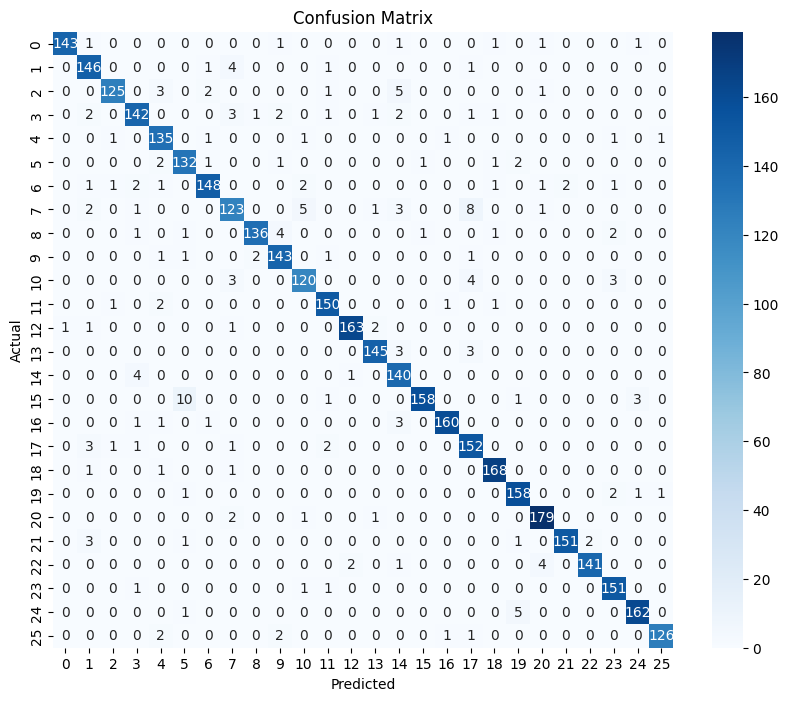


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       149
           1       0.91      0.95      0.93       153
           2       0.97      0.91      0.94       137
           3       0.93      0.91      0.92       156
           4       0.91      0.96      0.93       141
           5       0.90      0.94      0.92       140
           6       0.96      0.93      0.94       160
           7       0.89      0.85      0.87       144
           8       0.98      0.93      0.95       146
           9       0.93      0.96      0.95       149
          10       0.92      0.92      0.92       130
          11       0.95      0.97      0.96       155
          12       0.98      0.97      0.98       168
          13       0.97      0.96      0.96       151
          14       0.89      0.97      0.92       145
          15       0.99      0.91      0.95       173
          16       0.98      0.96      0.97       166
  

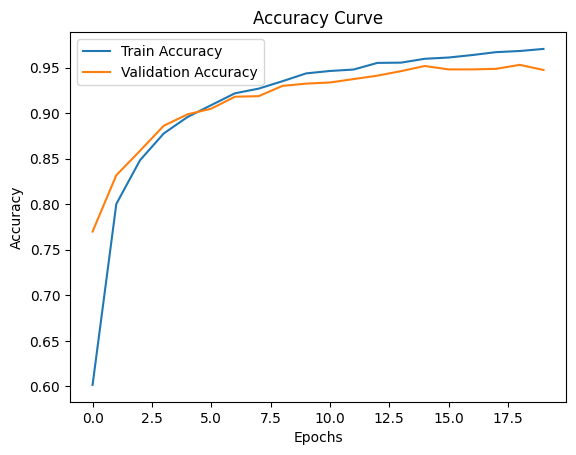

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
data = pd.read_csv(r"/content/letter-recognition.data", header=None)

# Split features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Encode labels (A-Z → 0-25)
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model (store history for curves)
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# ----------------------------
# 🔷 Accuracy on test data
# ----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

# ----------------------------
# 🔷 Predictions
# ----------------------------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ----------------------------
# 🔷 Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
# 🔷 Classification Report
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

# ----------------------------
# 🔷 Accuracy Curve
# ----------------------------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
